e:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Classes: ['Anthracnose', 'Bacterial_Canker', 'Die_Back', 'Gall_Mid', 'healthy']
Train: 2100  Val: 450  Test: 450
Extracting features...


100%|██████████| 450/450 [01:04<00:00,  6.93it/s]


Feature shapes:
Train: (2100, 768)
Val  : (450, 768)
Test : (450, 768)
ViTHead(
  (dropout): Dropout(p=0.4, inplace=False)
  (head): LoRALinear(
    (linear): Linear(in_features=768, out_features=5, bias=False)
    (lora_a): Linear(in_features=768, out_features=4, bias=False)
    (lora_b): Linear(in_features=4, out_features=5, bias=False)
  )
)
Epoch 1/50 - Train Loss: 1.5968  Val Loss: 1.5622
Epoch 2/50 - Train Loss: 1.5689  Val Loss: 1.5312
Epoch 3/50 - Train Loss: 1.5344  Val Loss: 1.5015
Epoch 4/50 - Train Loss: 1.5131  Val Loss: 1.4727
Epoch 5/50 - Train Loss: 1.4923  Val Loss: 1.4450
Epoch 6/50 - Train Loss: 1.4616  Val Loss: 1.4183
Epoch 7/50 - Train Loss: 1.4308  Val Loss: 1.3923
Epoch 8/50 - Train Loss: 1.4027  Val Loss: 1.3671
Epoch 9/50 - Train Loss: 1.3773  Val Loss: 1.3427
Epoch 10/50 - Train Loss: 1.3547  Val Loss: 1.3189
Epoch 11/50 - Train Loss: 1.3414  Val Loss: 1.2958
Epoch 12/50 - Train Loss: 1.3163  Val Loss: 1.2733
Epoch 13/50 - Train Loss: 1.2882  Val Loss: 1.2516

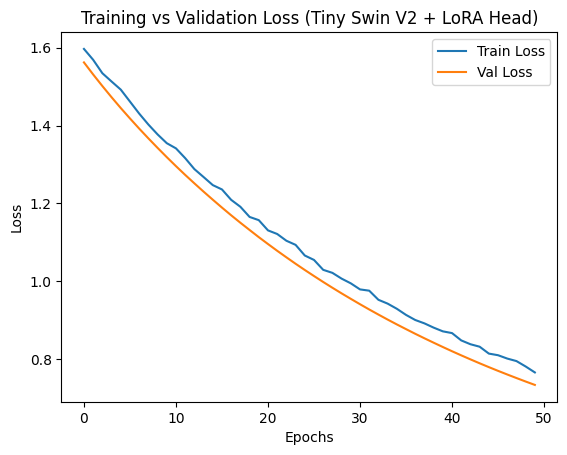


Final Test Metrics (Tiny Swin V2 + LoRA Head):
Accuracy  : 0.8800
Precision : 0.8779
Recall    : 0.8800
F1 Score  : 0.8767


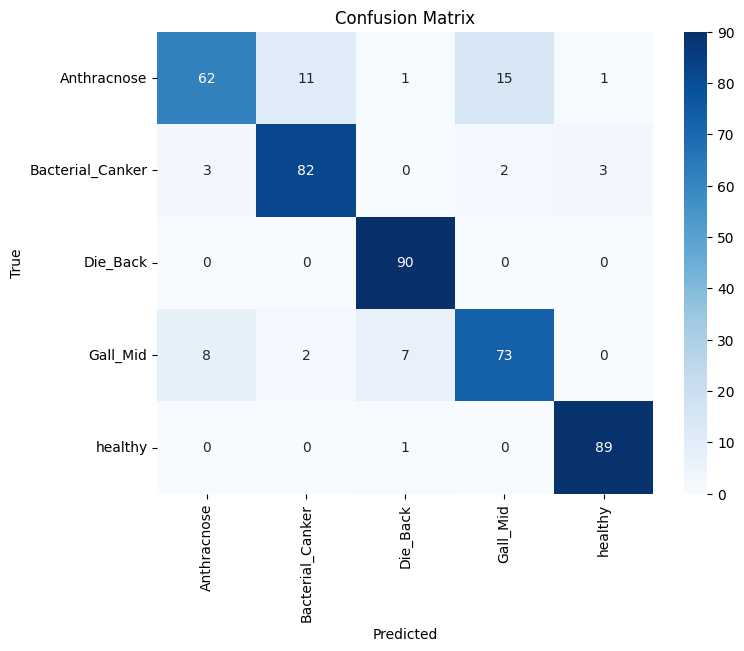

In [1]:
# =========================
# Imports & Device Setup
# =========================
import os, glob, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# =========================
# Dataset Paths & Split
# =========================
DATASET_DIR = r"E:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\dataset2"  # <-- Update path if needed
IMG_SIZE = 224

# Classes
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

# Image paths and labels
image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

# =========================
# Minimal Image Transforms
# =========================
# Just resize, to tensor, normalize (no augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# Feature Extraction (Tiny Swin V2)
# =========================
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

print("Extracting features...")
X_train_feats = np.stack([extract_feature_from_path(p, train_transform) for p in tqdm(X_train_paths)])
X_val_feats   = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats  = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])

print("Feature shapes:")
print("Train:", X_train_feats.shape)
print("Val  :", X_val_feats.shape)
print("Test :", X_test_feats.shape)


# =========================
# LoRA-adapted ViT Head (with hyperparameters)
# =========================
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=4):   #rank
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)

    def forward(self, x):
        return self.linear(x) + self.lora_b(self.lora_a(x))


class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes, dropout_rate=0.4):  #dropout rate
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.head = LoRALinear(in_features, num_classes, r=4)

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.head(self.dropout(x)).squeeze(0)
        return self.head(self.dropout(x))


# =========================
# Initialize Head Model
# =========================
in_features = X_train_feats.shape[1]
num_classes = len(CLASS_NAMES)

model_head = ViTHead(in_features, num_classes, dropout_rate=0.4).to(device)
print(model_head)



# =========================
# Dataloaders
# =========================
batch_size = 64
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_feats, dtype=torch.float32),
                                        torch.tensor(y_train, dtype=torch.long)),
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32),
                                      torch.tensor(y_val, dtype=torch.long)),
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32),
                                       torch.tensor(y_test, dtype=torch.long)),
                         batch_size=batch_size, shuffle=False)

# =========================
# Training Loop with Early Stopping
# =========================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_head.parameters(), lr=1e-5, weight_decay=1e-4)

EPOCHS = 50
PATIENCE = 5
best_val_loss = float("inf")
wait = 0
best_model_path = "tinyswin_lora.pth"

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # Training
    model_head.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation
    model_head.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model_head(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model_head.state_dict(), best_model_path)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# =========================
# Plot Losses
# =========================
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Tiny Swin V2 + LoRA Head)")
plt.legend()
plt.show()

# =========================
# Evaluation
# =========================
model_head.load_state_dict(torch.load(best_model_path))
model_head.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model_head(xb)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_true.extend(yb.numpy())
        y_pred.extend(preds)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")

print("\nFinal Test Metrics (Tiny Swin V2 + LoRA Head):")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()